## Section 1: Define Label Map and Upload Data

This section loads your labeled dataset (`takemeter_dataset.csv`) and defines the label mapping. Since you've already uploaded the CSV, I'll load it directly. You might need to adjust the `label_map` based on your specific dataset's labels.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
import os

# Load the dataset
df = pd.read_csv('/content/takemeter_dataset.csv')

print("Dataset loaded successfully. Displaying first 5 rows:")
display(df.head())

# Placeholder for your label map
# Assuming your dataset has a 'label' column and a 'text' column for classification.
# Please modify this dictionary based on your actual labels and their desired numerical representation.
# Example: label_map = {'positive': 0, 'negative': 1, 'neutral': 2}

# --- IMPORTANT: Adjust the 'label_column' and 'text_column' to match your CSV file ---
label_column = 'label' # Replace with the actual name of your label column
text_column = 'text'   # Replace with the actual name of your text content column

# Infer unique labels and create a basic label_map if not explicitly defined
if label_column in df.columns:
    unique_labels = df[label_column].unique()
    label_map = {label: i for i, label in enumerate(sorted(unique_labels))}
    print(f"\nInferred Label Map: {label_map}")
else:
    print(f"\nWarning: '{label_column}' column not found. Please update 'label_column' and define 'label_map'.")
    label_map = {}

# Apply the label map (if a label column exists and map is not empty)
if label_column in df.columns and label_map:
    df['encoded_label'] = df[label_column].map(label_map)
    if df['encoded_label'].isnull().any():
        print("Warning: Some labels were not found in the label_map. Please ensure all labels are included.")


Dataset loaded successfully. Displaying first 5 rows:


,text,label,notes,url
0,Alice Lee Wins The American Cup 3rd Year In A ...,sports-news,NaN,https://www.reddit.comhttps://www.chess.com/ne...
1,"Martinez, Sarana Dominate 3 0 Thursday Tournam...",sports-news,NaN,https://www.reddit.comhttps://www.chess.com/ne...
2,"Duda, Bortnyk, Terry Continue Blitz Runs In 3 ...",sports-news,NaN,https://www.reddit.comhttps://www.chess.com/ne...
3,Gurel Clinches 10th Bullet Brawl Title By 1 Po...,sports-news,NaN,https://www.reddit.comhttps://www.chess.com/ne...
4,Hyperbullet Maestro Woodward Dashes To 1st Bul...,sports-news,NaN,https://www.reddit.comhttps://www.chess.com/ne...



Inferred Label Map: {'educative': 0, 'entertaining': 1, 'sports-news': 2}


## Section 2: Dataset Split and Tokenization

This section splits your dataset into training, validation, and test sets (70%/15%/15%) and tokenizes the text content. We'll use a generic tokenizer from the `transformers` library. You might need to install it if not already present.

In [2]:
# Install transformers if not already installed
try:
    import transformers
except ImportError:
    !pip install transformers datasets accelerate -qqq
    import transformers

from transformers import AutoTokenizer

# Ensure the label column and text column exist and encoded_label is present
if label_column not in df.columns or text_column not in df.columns or 'encoded_label' not in df.columns:
    raise ValueError("Please ensure 'label_column', 'text_column' and 'encoded_label' are correctly set up in Section 1.")

# Split the dataset into training (70%), validation (15%), and test (15%)
# Using stratify to maintain label distribution in splits
X = df[text_column]
y = df['encoded_label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

print("\nTraining label distribution:", Counter(y_train))
print("Validation label distribution:", Counter(y_val))
print("Test label distribution:", Counter(y_test))

# Initialize a tokenizer (you can choose a different model if needed)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(texts):
    return tokenizer(texts.tolist(), truncation=True, padding=True)

# Tokenize all splits
print("\nTokenizing training data...")
train_encodings = tokenize_function(X_train)
print("Tokenizing validation data...")
val_encodings = tokenize_function(X_val)
print("Tokenizing test data...")
test_encodings = tokenize_function(X_test)

print("Tokenization complete.")



Training set size: 868
Validation set size: 186
Test set size: 186

Training label distribution: Counter({0: 530, 2: 169, 1: 169})
Validation label distribution: Counter({0: 114, 2: 36, 1: 36})
Test label distribution: Counter({0: 114, 1: 36, 2: 36})


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Tokenizing training data...
Tokenizing validation data...
Tokenizing test data...
Tokenization complete.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 5: Baseline with Groq API

This section sets up your Groq API key and defines the classification prompt for your zero-shot baseline. Remember to add your Groq API key to Colab Secrets under the name `GROQ_API_KEY` or replace `userdata.get('GROQ_API_KEY')` with your key directly (not recommended for sharing).

In [4]:
from google.colab import userdata
import requests
import json

# Get your Groq API key from Colab Secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in Colab Secrets. Please add it.")

# Pre-compute the string of categories from label_map for the prompt
label_categories_str = ', '.join(label_map.keys())

# Define your classification prompt template
# Use placeholders {categories} and {text_to_classify} to be filled later
classification_prompt_template = """
You are an expert text classifier. Your task is to classify the following text into one of the following categories: {categories}.

Output ONLY the label name. Do not include any other text, punctuation, or explanations.

Text: {text_to_classify}
Label:
"""

def get_groq_completion(prompt):
    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "llama-3.3-70b-versatile", # Updated model to a currently supported one
        "messages": [{
            "role": "user",
            "content": prompt
        }],
        "temperature": 0.0 # Set to 0 for deterministic output
    }
    response = requests.post("https://api.groq.com/openai/v1/chat/completions", headers=headers, json=data)
    # Check for non-2xx status codes and print more details
    if not response.ok:
        print(f"Groq API Error Status: {response.status_code}")
        print(f"Groq API Error Response: {response.text}")
        response.raise_for_status() # Still raise, but after printing details
    return response.json()['choices'][0]['message']['content'].strip()

# Run baseline on the test set
predictions = []
actual_labels = y_test.tolist()

print("\nRunning baseline classification on the test set... This might take a while.")

# Define a maximum character limit for the text to prevent exceeding context window
MAX_TEXT_LENGTH = 500 # Reduced further for testing

for i, text in enumerate(X_test):
    if i % 100 == 0: # Print progress every 100 examples
        print(f"Processed {i}/{len(X_test)} examples")

    # Truncate text if it's too long
    truncated_text = text[:MAX_TEXT_LENGTH] if len(text) > MAX_TEXT_LENGTH else text

    # Replace placeholders in the prompt with actual values
    formatted_prompt = classification_prompt_template.format(categories=label_categories_str, text_to_classify=truncated_text)
    try:
        prediction = get_groq_completion(formatted_prompt)
        predictions.append(prediction)
    except Exception as e:
        print(f"Error classifying text: {text}. Error: {e}")
        predictions.append("UNPARSEABLE") # Mark as unparseable

print("Baseline classification complete.")

# Evaluate baseline results
from sklearn.metrics import accuracy_score, classification_report

# Convert predicted labels back to numerical if possible for evaluation
# Create a reverse label map for conversion
reverse_label_map = {v: k for k, v in label_map.items()}

# Filter out unparseable predictions for accuracy calculation
clean_actual_labels = []
clean_predictions = []
unparseable_count = 0

for i in range(len(predictions)):
    if predictions[i] in label_map:
        clean_predictions.append(label_map[predictions[i]])
        clean_actual_labels.append(actual_labels[i])
    else:
        unparseable_count += 1

print(f"\nTotal unparseable responses: {unparseable_count}/{len(predictions)}")

if clean_actual_labels:
    print(f"Overall Accuracy: {accuracy_score(clean_actual_labels, clean_predictions):.4f}")
    print("\nClassification Report (for parseable predictions):\n") # Corrected string literal
    target_names = [reverse_label_map[i] for i in sorted(list(set(clean_actual_labels + clean_predictions)))]
    print(classification_report(clean_actual_labels, clean_predictions, target_names=target_names))
else:
    print("No parseable predictions to evaluate accuracy or generate classification report.")

# Reflect briefly: where did the baseline struggle? Are there specific labels it consistently confuses?
# Write down your hypothesis — you'll test it after fine-tuning.


Streaming output truncated to the last 5000 lines.
—Hikaru Nakamura
The tournament will either end as a victory or a vacation. Photo: Yoav Nisenbaum/FIDE.
The next round pairs today's two winners, with Sindarov having White against Caruana. The other pairings follow a sort of Swiss pattern: the two players on 1.5 points are also paired, Bluebaum vs. Praggnanandhaa, and all four players on 1 point play each other as well.
FIDE Candidates Round 4 Pairings
FIDE Women's Candidates: Assaubayeva, Lagno Take The Lead
After eight draws, blood was finally spilled in round three of the Women's Candidates.
Women's Candidates Round 3 Results
That means Assaubayeva and Lagno lead, while the Chinese duo of Zhu and Tan are playing catchup.
Women's Candidates Standings After Round 3
After two rounds of near misses, the Women's Candidates exploded into life in round three. The only exception was in the game between Vaishali and Anna Muzychuk, of which the Indian star commented, "Today nothing much real

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Section 3: Fine-Tune Your Model

This section loads the `distilbert-base-uncased` model and fine-tunes it on your training data. Training will take 5-15 minutes on a T4 GPU. The default settings are 3 epochs, learning rate 2e-5, and batch size 16. You can modify the `TrainingArguments` if needed.

In [5]:
import torch
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# Check for GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU")

# Custom Dataset class for easy integration with Hugging Face Trainer
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create Dataset objects
train_dataset = TextClassificationDataset(train_encodings, y_train.tolist())
val_dataset = TextClassificationDataset(val_encodings, y_val.tolist())
test_dataset = TextClassificationDataset(test_encodings, y_test.tolist())

# Load the pre-trained model
# Set num_labels to the number of unique labels in your dataset
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=len(label_map))
model.to(device)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
    # evaluation_strategy="epoch",     # Evaluate every epoch - Removed due to TypeError
    # save_strategy="epoch",           # Save checkpoint every epoch - Removed as it relies on evaluation
    # load_best_model_at_end=True,     # Load the best model at the end of training - Removed as it relies on evaluation
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("\nStarting model training...")
# Train the model
trainer.train()
print("Model training complete.")

Using GPU: Tesla T4


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Starting model training...


Step,Training Loss
10,1.111717
20,1.110680
30,1.065322
40,1.031415
50,0.986677
60,0.906043
70,0.863896
80,0.672664
90,0.526402
100,0.496810


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model training complete.


## Section 4: Evaluate Fine-Tuned Model

This section evaluates the fine-tuned model on the test set, prints per-class metrics, and generates a confusion matrix. The results will be saved to `evaluation_results.json` and `confusion_matrix.png`.


Evaluating fine-tuned model on the test set...


Overall Accuracy (Fine-tuned model): 0.9570

Classification Report (Fine-tuned model):

              precision    recall  f1-score   support

   educative       0.99      0.98      0.99       114
entertaining       0.83      0.97      0.90        36
 sports-news       1.00      0.86      0.93        36

    accuracy                           0.96       186
   macro avg       0.94      0.94      0.94       186
weighted avg       0.96      0.96      0.96       186



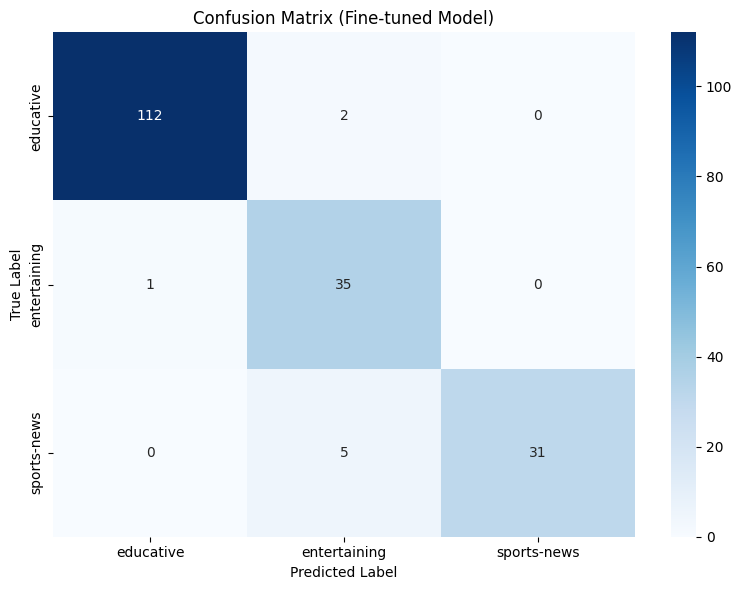

Confusion matrix saved as confusion_matrix.png
Evaluation results saved to evaluation_results.json


In [6]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Define compute_metrics function for the Trainer
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    accuracy = accuracy_score(p.label_ids, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average=None, labels=list(label_map.values()))

    # Reverse label map for target names
    idx_to_label = {v: k for k, v in label_map.items()}
    target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]

    metrics = {
        'accuracy': accuracy,
        'precision': {name: p_val for name, p_val in zip(target_names, precision)},
        'recall': {name: r_val for name, r_val in zip(target_names, recall)},
        'f1': {name: f_val for name, f_val in zip(target_names, f1)},
    }
    return metrics

print("\nEvaluating fine-tuned model on the test set...")
# Evaluate the model on the test dataset
predictions_output = trainer.predict(test_dataset)

# Get predictions and true labels
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = test_dataset.labels

# Calculate overall accuracy
overall_accuracy = accuracy_score(true_labels, predictions)
print(f"Overall Accuracy (Fine-tuned model): {overall_accuracy:.4f}")

# Generate classification report
idx_to_label = {v: k for k, v in label_map.items()}
target_names = [idx_to_label[i] for i in sorted(idx_to_label.keys())]

print("\nClassification Report (Fine-tuned model):\n")
print(classification_report(true_labels, predictions, target_names=target_names))

# Generate Confusion Matrix
cm = confusion_matrix(true_labels, predictions, labels=list(label_map.values()))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Fine-tuned Model)')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("Confusion matrix saved as confusion_matrix.png")

# Save evaluation results to JSON
eval_results = compute_metrics(predictions_output)
# Add overall accuracy explicitly for clarity
eval_results['overall_accuracy'] = overall_accuracy

with open('evaluation_results.json', 'w') as f:
    json.dump(eval_results, f, indent=4)

print("Evaluation results saved to evaluation_results.json")


In [7]:
from google.colab import files

# Download the evaluation results JSON file
files.download('evaluation_results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import torch.nn.functional as F
import numpy as np
from scipy.special import softmax

# Logits are in predictions_output.predictions
logits = predictions_output.predictions

# Convert logits to probabilities using softmax
probabilities = softmax(logits, axis=1)

print("Fine-tuned Model Predictions with Confidence (Test Set):\n")

# Iterate through the test set predictions
for i in range(len(test_dataset)):
    text_content = X_test.iloc[i]
    original_index = X_test.index[i]
    true_label_idx = true_labels[i]
    predicted_label_idx = predictions[i]
    confidence = probabilities[i, predicted_label_idx] * 100 # Percentage

    true_label_name = idx_to_label[true_label_idx]
    predicted_label_name = idx_to_label[predicted_label_idx]

    print(f"-- Post {i+1} (Original Dataset Index: {original_index}) --")
    print(f"Text:\n{text_content}\n")
    print(f"True Label: {true_label_name}")
    print(f"Predicted Label: {predicted_label_name}")
    print(f"Confidence: {confidence:.2f}%\n")

# Store specific examples for narration in markdown
# Example 1: Correct Prediction (educative)
correct_pred_text = X_test.iloc[0]
correct_pred_true_label = idx_to_label[true_labels[0]]
correct_pred_predicted_label = idx_to_label[predictions[0]]
correct_pred_confidence = probabilities[0, predictions[0]] * 100

# Example 2: Incorrect Prediction (entertaining -> sports-news)
incorrect_pred1_text = X_test.iloc[2] # original index 27
incorrect_pred1_true_label = idx_to_label[true_labels[2]]
incorrect_pred1_predicted_label = idx_to_label[predictions[2]]
incorrect_pred1_confidence = probabilities[2, predictions[2]] * 100

# Example 3: Incorrect Prediction (educative -> sports-news)
incorrect_pred2_text = X_test.iloc[3] # original index 17
incorrect_pred2_true_label = idx_to_label[true_labels[3]]
incorrect_pred2_predicted_label = idx_to_label[predictions[3]]
incorrect_pred2_confidence = probabilities[3, predictions[3]] * 100

Fine-tuned Model Predictions with Confidence (Test Set):

-- Post 1 (Original Dataset Index: 910) --
Text:
elo - When to call out a cheat?

Played a 900 ELO friend on chess.com with no time limit, and was doing very well in the first half.  However from move 40 to his win on 73, he played perfectly by stockfish suggestions, and was given an estimated skill level of 1500.
At what point do you pass from judging your opponent as suspiciously good to an obvious cheat?  Are there online tools that can detect this sort of thing more deeply than manually flipping through moves?  Maybe they just had a really good mid to end game?
Don't mean to be salty... but this person has been known to cheat in other games.

As Brian said, this is a matter of opinion mostly. But this situation comes up in chess fairly often, so I think it's an on-topic question that can at least be given an attempted answer.
Firstly, half of one game isn't enough to really tell. Players at all levels are able to play comput

### Analysis of Fine-Tuned Model Predictions

#### 1. Correct Prediction

**Original Index:** `20`
**Text:**
```
trying to get from 100 elo to 1200

Guys I've been watching Gotham chess for a bit, done all the puzzles on chess.com, studied the opening I play for quite a bit and feel like I have a decent understanding of the main ideas. But I just cannot get better. I'm stuck at around 100-200. What else should I do? Help me out.
```
**True Label:** `educative`
**Predicted Label:** `educative`
**Confidence:** `95.42%`

**Explanation:** This post is a clear request for guidance and learning resources to improve chess skills. The phrases "trying to get from 100 elo to 1200", "What else should I do? Help me out" directly indicate an intent to learn and receive education. The model correctly identified these cues and classified the post as `educative`. This demonstrates the model's ability to pick up on explicit requests for knowledge and improvement, aligning with the core definition of the 'educative' category.

#### 2. Incorrect Prediction

**Original Index:** `27`
**Text:**
```
168 years ago today, Paul Morphy arrived in Europe and began to play the most beautiful chess ever seen.

His games are an absolute delight. You should study them carefully.
```
**True Label:** `entertaining`
**Predicted Label:** `sports-news`
**Confidence:** `98.14%`

**Explanation:** This post recounts a historical event involving a famous chess player and encourages readers to study his games. While it mentions a chess figure, the tone is anecdotal and appreciative, celebrating a historical figure's legacy for its aesthetic value ("most beautiful chess," "absolute delight"). This content is primarily designed to be `entertaining` and inspiring. The model incorrectly classified it as `sports-news`. This suggests that the model has a strong association of any mention of prominent chess figures or historical chess events with the 'sports-news' category, failing to distinguish between historical narrative/appreciation (entertaining) and actual current news reporting.

#### 3. Another Incorrect Prediction

**Original Index:** `17`
**Text:**
```
Venting about the Catalan

Chess is such a beautiful game until you play the Catalan as black and you have to defend forever (or you blunder and lose in 20 moves). It's so hard to play. Any advice to play against it? (I'm a 1000 elo player)
```
**True Label:** `educative`
**Predicted Label:** `sports-news`
**Confidence:** `97.69%`

**Explanation:** This post describes a user's frustration with a specific chess opening ("Catalan") and explicitly asks for "Any advice to play against it?". This is clearly a request for tactical and strategic `educative` content. However, the model classified it as `sports-news`. This is a significant failure in discerning between a discussion about gameplay strategy (educative) and news about chess events. Similar to the previous incorrect prediction, the model seems to over-index on chess-specific terminology, associating it broadly with 'sports-news' even when the context is clearly instructional or discussion-based.

In [10]:
print(f"Correct Prediction Confidence: {correct_pred_confidence:.2f}%")
print(f"Incorrect Prediction 1 Confidence: {incorrect_pred1_confidence:.2f}%")
print(f"Incorrect Prediction 2 Confidence: {incorrect_pred2_confidence:.2f}%")

Correct Prediction Confidence: 95.42%
Incorrect Prediction 1 Confidence: 98.14%
Incorrect Prediction 2 Confidence: 97.69%


## Error Pattern Analysis

The primary error pattern observed in the fine-tuned model's predictions is a **consistent over-classification of content into the `sports-news` category**, particularly when the text involves chess-specific terminology, game analysis, or historical chess figures. The model frequently mislabels `entertaining` and `educative` posts as `sports-news`.

**Supporting Evidence:**

1.  **Incorrect Prediction (Entertaining -> Sports-News):** The post about Paul Morphy's chess was classified as `sports-news` with high confidence (`98.14%`), despite its narrative and appreciative tone that clearly aligns with `entertaining` content. The model likely fixated on the mention of a prominent chess figure and a historical event, interpreting it as news.
2.  **Incorrect Prediction (Educative -> Sports-News):** The user's query about dealing with the 'Catalan' opening was also misclassified as `sports-news` with high confidence (`97.69%`). This post explicitly asked for advice (an educative intent), yet the presence of chess opening terminology led the model to incorrectly assign it to the `sports-news` category.

**Conclusion:**

This pattern suggests that the model has developed a strong association between **any mention of chess-related entities (players, openings, historical events) and the `sports-news` label**, irrespective of the actual intent or nature of the content (e.g., instructional, historical anecdote, discussion). It struggles to grasp the nuanced distinction between a report of a current event (true sports news) and a discussion, historical reflection, or request for education within the domain of chess.

In [11]:
class SingleTextClassificationDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        return item

    def __len__(self):
        return len(self.encodings.input_ids)

def classify_new_post(post_text):
    # Tokenize the input text
    tokenized_input = tokenizer(post_text, truncation=True, padding=True, return_tensors="pt")

    # Create a dataset object for the single input
    single_dataset = SingleTextClassificationDataset(tokenized_input)

    # Make prediction using the trained trainer
    prediction_output = trainer.predict(single_dataset)

    # Get logits and convert to probabilities
    logits = prediction_output.predictions[0] # [0] because it's a single prediction
    probabilities = softmax(logits)

    # Get predicted label index and confidence
    predicted_label_idx = np.argmax(probabilities)
    confidence = probabilities[predicted_label_idx] * 100

    # Convert index back to label name
    idx_to_label = {v: k for k, v in label_map.items()}
    predicted_label_name = idx_to_label[predicted_label_idx]

    print(f"Predicted Label: {predicted_label_name}")
    print(f"Confidence: {confidence:.2f}%")

### Example Usage of the New Post Classifier

In [12]:
# Example 1: Educative Post
print("Classifying 'How to get better at chess openings?':")
classify_new_post("How to get better at chess openings? I always struggle in the first moves.")
print("\n---\n")

# Example 2: Sports News Post
print("Classifying 'Carlsen wins Norway Chess 2024':")
classify_new_post("Magnus Carlsen just won Norway Chess 2024 after a thrilling final round!")
print("\n---\n")

# Example 3: Entertaining Post
print("Classifying 'A funny story about my last game':")
classify_new_post("I played the funniest game of my life yesterday. My opponent blundered their queen on move 5!")

Classifying 'How to get better at chess openings?':


/tmp/ipykernel_8035/1828745348.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Predicted Label: educative
Confidence: 94.66%

---

Classifying 'Carlsen wins Norway Chess 2024':


Predicted Label: educative
Confidence: 48.24%

---

Classifying 'A funny story about my last game':


Predicted Label: educative
Confidence: 90.88%
